# Count map from $m_5$

In [1]:
import numpy as np
import dask.array as da
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import healpy as hp
import matplotlib.pyplot as plt
import pyccl as ccl

from simulMap import *
from fitMap import *
from lumMag_sampling import *
from mappers import DepthMapper, CountMapper
from spectra import Spectrum

# Set random seed for reproducibility
#np.random.seed(42)

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

Number of pixels = 49152


## $m_5$ magnitude

Saving m5map_band_i in ../Figures/Reza_Figures/Magnitude/m5map_band_i.pdf


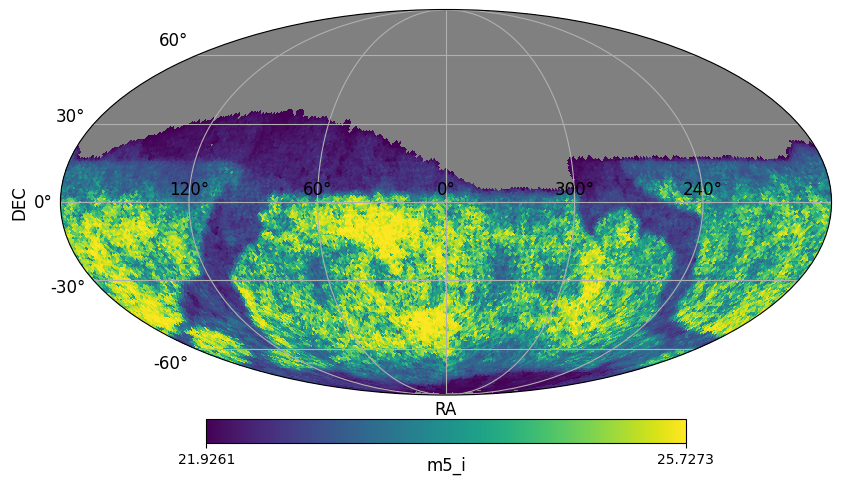

In [3]:
DIR = '../data/'
FILE = DIR + "baseline_v5.0.0_10yrs_summary.hdf5"
dm = DepthMapper.read_hdf(FILE)
dm.select_year(1)
band = 'i'
dm.select_band(band)
dm.set_mask()
dm.plot()

output_path = "../Figures/Reza_Figures/Magnitude/"
get_savefig(plt, output_path, f"m5map_band_{band}")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 316.7 (χ²/ndof = 0.0)      │              Nfcn = 741              │
│ EDM = 2.13e-05 (Goal: 0.0002)    │           time = 11.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  24.805   │   0.035   │   -0.035   │   0.035    │    0    │         │       │
│ 1 │ A    │  0.0222   │  0.0027   │  -0.0027   │   0.0027   │    0    │    1    │       │
│ 2 │ ra   │    259    │    25     │    -26     │     25     │    0    │   360   │       │
│ 3 │ dec  │    -79    │     5     │     -5     │     5      │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.035   │   0.035   │  -0.0027  │  0.0027   │    -26    │    26     │    -5     │     5     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────┐
│     │        N*         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│  N* │   0.00124    -59e-6    0.0844    0.0559 │
│   A │    -59e-6   7.3e-06 -5.470e-3 -3.961e-3 │
│  ra │    0.0844 -5.470e-3       625         5 │
│ dec │    0.0559 -3.961e-3         5      24.8 │
└─────┴─────────────────────────────────────────┘

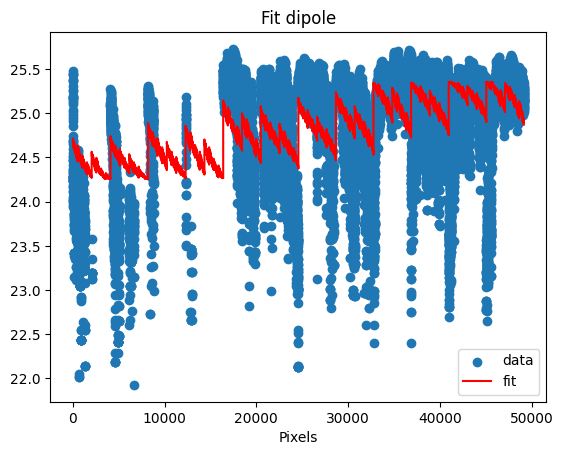

In [4]:
init =  (10, 1, 100, 40)
m = dm.fit_dipole("iMasked", init, plot_map=False)
m

## Reference spectrum

Saving SED_Gal in ../Figures/SED_Figures/SED_Galaxies/SED_Gal.pdf
SED bolometric integral : -4469521748671.2


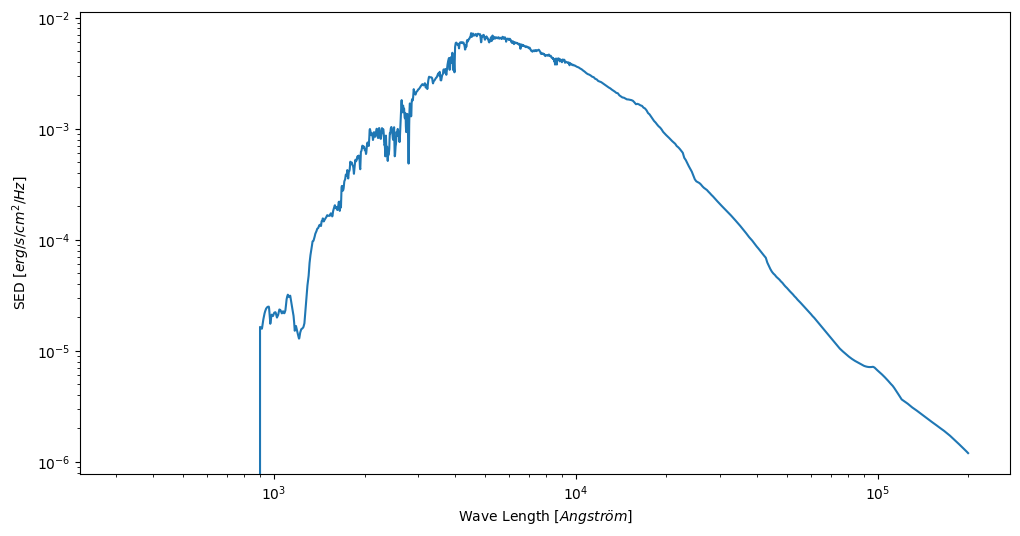

In [5]:
file = "../data/data SED/SED GAL/COSMOS/Ell1_A_0.sed"
refSpectum = Spectrum.read_sed(file)
refSpectum.plot(loglog=True, title="")

output_path = "../Figures/SED_Figures/SED_Galaxies/"
get_savefig(plt, output_path, "SED_Gal")

integral = refSpectum.integrate()
print(f"SED bolometric integral : {integral}")

Saving SED_Response in ../Figures/SED_Figures/SED_Galaxies/SED_Response.pdf


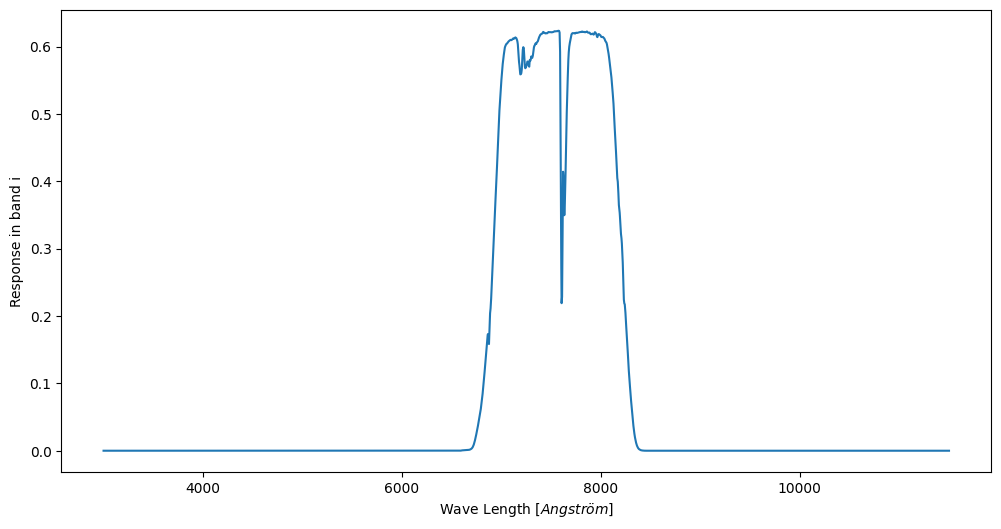

In [6]:
#band = 'i'
file_band = f"../data/data LSST/total_{band}.dat"
responseSpectrum = Spectrum.read_sed(file_band, yname=f"Response in band {band}", yunit="")
responseSpectrum.wavelength = responseSpectrum.wavelength*10
responseSpectrum.plot(loglog=False, title="")

output_path = "../Figures/SED_Figures/SED_Galaxies/"
get_savefig(plt, output_path, "SED_Response")

In [7]:
_, response = refSpectum.get_surrounding(responseSpectrum)
response = response.mean(axis=0)
L_bandRatio = refSpectum.ratio_integrate(response)
print(f"SED band {band} ratio : {L_bandRatio}")

SED band i ratio : 0.045453330734618005


## Ratio determination

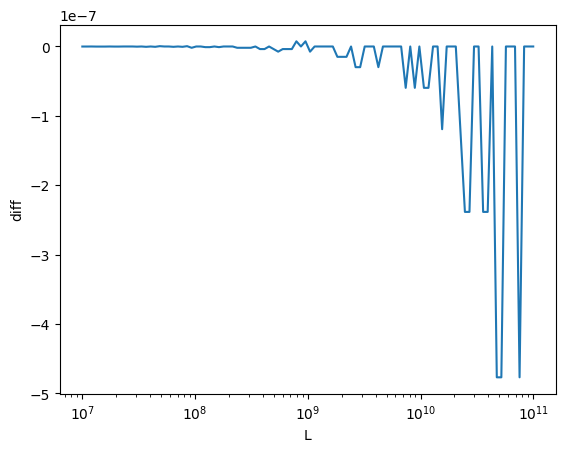

In [8]:
L=np.logspace(7, 11, 100)
Ldf = pd.DataFrame({"L": L})
diff = np.array(Ldf['L'].apply(lumBolom2lumBand, args=(refSpectum, response, True))) - L*L_bandRatio
plt.plot(L, diff)
plt.xlabel('L')
plt.ylabel('diff')
plt.xscale('log')
#plt.yscale('log');

In [9]:
NSource_px_th = int(1e6)
#dataN = generate_lumMag(NSource_px_th, to_table=True, sed=refSpectum, response=response, renorm=True)
dataN = generate_lumMag(NSource_px_th, to_table=True, L_min=1e10, L_bandRatio=L_bandRatio)
dataN


Generating redshifts
Number of rejects = 690318
Accepted ratio = 76%

Generating dL

Generating luminosities
Number of rejects = 8799368
Accepted ratio = 10%


z,dL,L,M,m
,Mpc,solLum,,
float64,float64,float64,float64,float64
1.6074957951685795,12411.942322979481,1321776444.6048992,-17.972895020089496,27.496303723885443
0.3644530345101352,2034.0685894217063,937009954.3972541,-17.59936051168272,23.942467455206486
0.47416297948238284,2777.4406327160673,654598942.4573646,-17.20993824836144,25.008285675374793
0.863516838032172,5759.0609827625485,529570513.75809264,-16.979809489471037,26.82194889704639
0.869892765552957,5811.520865857823,462263685.60306025,-16.83222444394746,26.989224563284612
0.8535065045624203,5676.9009901957315,1283924265.4015026,-17.941348517104146,25.8292080820953
0.8485960502233229,5636.689669185533,696136268.1319191,-17.276735651846472,26.47838497402822
0.5612969779954667,3401.899614105546,1108094117.2684898,-17.78144162317065,24.877165846664095


Saving LumDist in Simul_Figures/Simul_Schechter/Schechter_LumDist.pdf


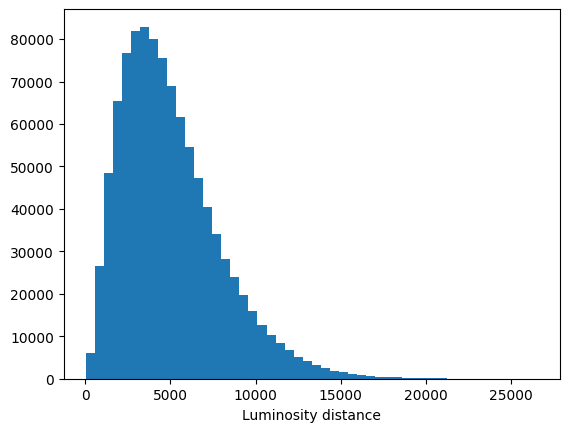

In [10]:
get_hist(dataN["dL"], xlabel='Luminosity distance', bins=50);

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "LumDist")

Saving LumDistLogLog in Simul_Figures/Simul_Schechter/Schechter_LumDistLogLog.pdf


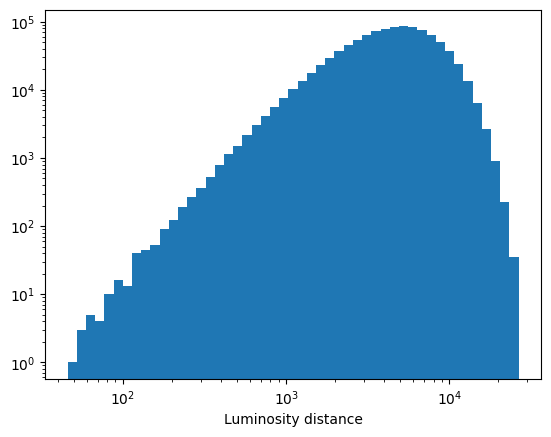

In [11]:
binsdL = np.logspace(np.log10(np.min(dataN["dL"])), np.log10(np.max(dataN["dL"])), 50)
get_hist(dataN["dL"], xlabel='Luminosity distance', bins=binsdL, log=True);
plt.xscale('log')

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "LumDistLogLog")

Saving ApparentMag_band_i in Simul_Figures/Simul_Schechter/Schechter_ApparentMag_band_i.pdf


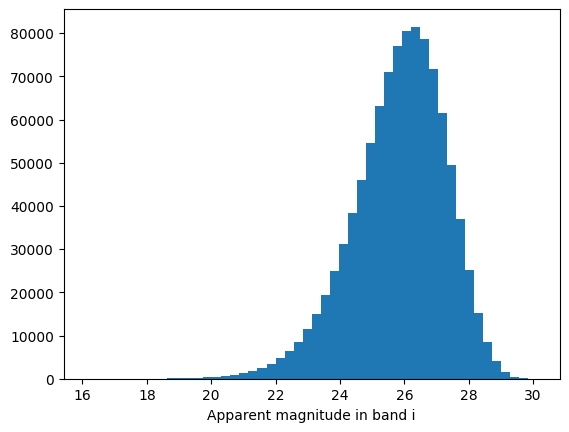

In [12]:
get_hist(dataN["m"], xlabel=f'Apparent magnitude in band {band}', bins=50, label="$m$")

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, f"ApparentMag_band_{band}")

Saving ApparentMag_cut_band_i in Simul_Figures/Simul_Schechter/Schechter_ApparentMag_cut_band_i.pdf


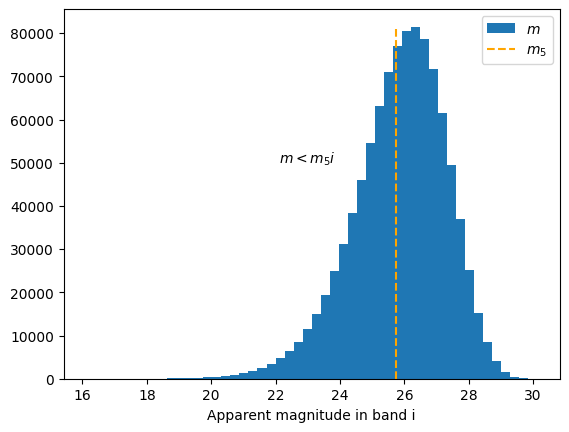

In [13]:
var, _ = get_hist(dataN["m"], xlabel=f'Apparent magnitude in band {band}', bins=50, label="$m$");
plt.vlines(dm.m5iMasked.max(), 0, var.max(), linestyles = 'dashed', colors="orange", label="$m_5$")
plt.text(22.1, 50000, f"$m < m_5{band}$")
plt.legend()

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, f"ApparentMag_cut_band_{band}")


Generating redshifts
Number of rejects = 689139
Accepted ratio = 77%

Generating dL

Generating luminosities
Number of rejects = 685862
Accepted ratio = 77%


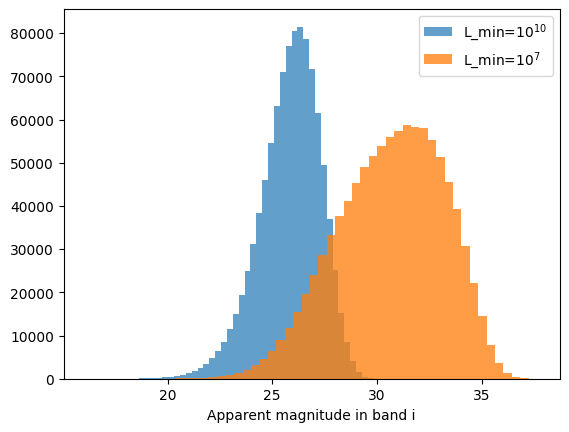

In [16]:
dataN2 = generate_lumMag(NSource_px_th, to_table=True, L_min=1e7, L_bandRatio=L_bandRatio)
fig, ax = plt.subplots()
get_hist(dataN["m"], xlabel=f'Apparent magnitude in band {band}', bins=50, alpha=0.7, label="L_min=$10^{10}$", figax=(fig, ax))
get_hist(dataN2["m"], xlabel=f'Apparent magnitude in band {band}', bins=50, alpha=0.77, label="L_min=$10^{7}$", figax=(fig, ax))
plt.legend();

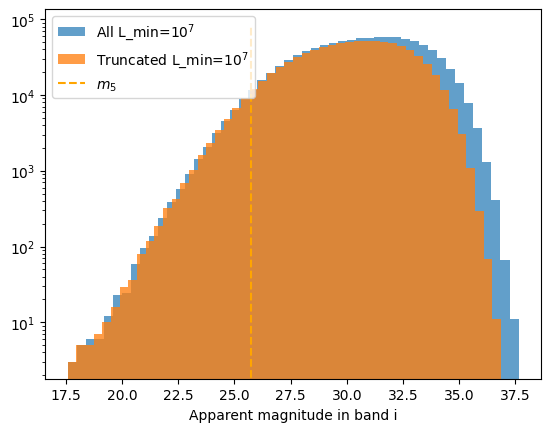

In [53]:
mask = dataN2['L']/L_bandRatio >= 2e7
m2 = dataN2['m'][mask]
fig, ax = plt.subplots()
get_hist(dataN2['m'], xlabel=f'Apparent magnitude in band {band}', bins=50, alpha=0.7, label="All L_min=$10^{7}$", figax=(fig, ax))
get_hist(m2, xlabel=f'Apparent magnitude in band {band}', bins=50, alpha=0.77, label="Truncated L_min=$10^{7}$", figax=(fig, ax))
plt.vlines(dm.m5iMasked.max(), 0, var.max(), linestyles = 'dashed', colors="orange", label="$m_5$")
plt.yscale('log')
plt.legend();

Saving CountMap_m5band_i in Simul_Figures/Simul_Magnitude/CountMap_m5band_i.pdf


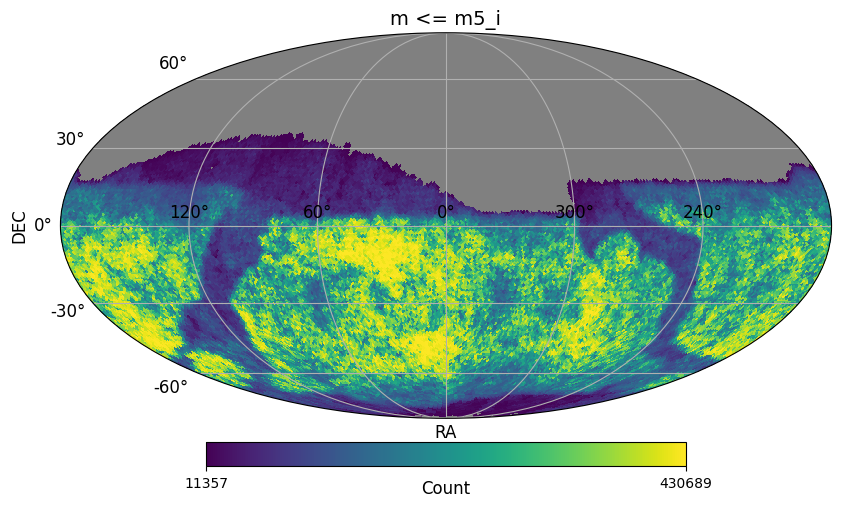

In [14]:
NSource_px = cut_m52map(dataN["m"], dm.m5i.copy())
countMapper = CountMapper.from_map(NSource_px)
countMapper.set_mask()
countMapper.plot("Masked", norm="hist", title= f"m <= m5_{band}")

output_path = "Simul_Figures/Simul_Magnitude/"
get_savefig(plt, output_path, f"CountMap_m5band_{band}")

Saving RatioMap_m5band_i in Simul_Figures/Simul_Magnitude/RatioMap_m5band_i.pdf


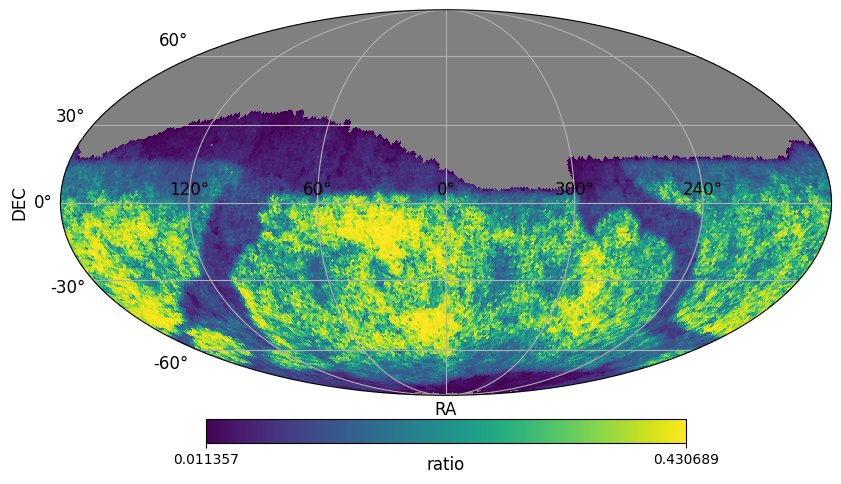

In [15]:
ratioMapper = CountMapper.from_map(countMapper.map/NSource_px_th)
ratioMapper._set_instance_settingsPlot(unit = 'ratio')
ratioMapper.set_mask()
ratioMapper.plot("Masked", norm="hist")

output_path = "Simul_Figures/Simul_Magnitude/"
get_savefig(plt, output_path, f"RatioMap_m5band_{band}")

## Souce sampling

Saving All_m_Map in Simul_Figures/Simul_Magnitude/All_m_Map.pdf


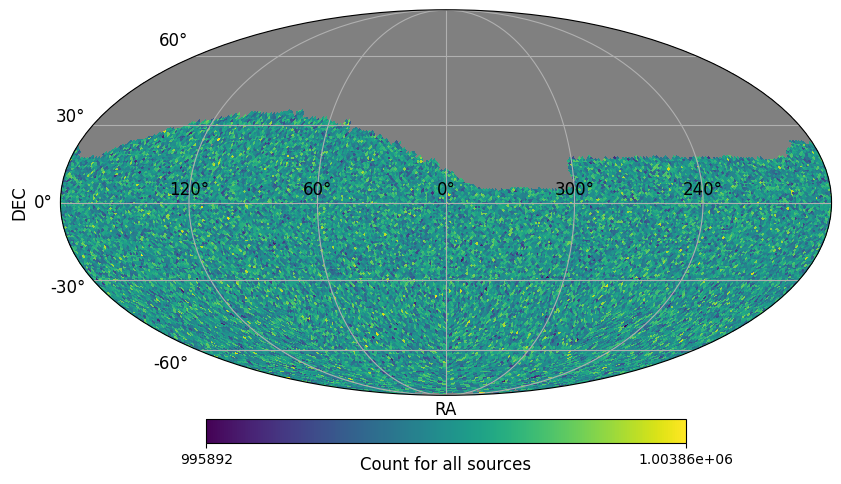

In [16]:
count_thMapper = CountMapper.from_map(np.random.poisson(NSource_px_th, npix))
count_thMapper._set_suffixTextPlot(unit = "all sources")
count_thMapper.set_mask(dm.m5iMasked.mask)
count_thMapper.plot("Masked")

output_path = "Simul_Figures/Simul_Magnitude/"
get_savefig(plt, output_path, "All_m_Map")

Unable to use minos()


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.282e+04 (χ²/ndof = 0.7)  │              Nfcn = 147              │
│ EDM = 4.24e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │1.000004e6 │0.000007e6 │-0.000007e6 │ 0.000007e6 │    0    │         │       │
│ 1 │ A    │ 0.011e-3  │ 0.013e-3  │ -0.011e-3  │  0.013e-3  │    0    │    1    │       │
│ 2 │ ra   │    240    │    80     │    -240    │    120     │    0    │   360   │       │
│ 3 │ dec  │    50     │    50     │            │            │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -7     │     7     │ -0.011e-3 │ 0.013e-3  │  -0.24e3  │  0.12e3   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   True    │   False   │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────┐
│     │           N*            A           ra          dec │
├─────┼─────────────────────────────────────────────────────┤
│  N* │         50.4  54.49474e-6           80          150 │
│   A │  54.49474e-6     1.67e-10 112.87096e-6 242.00546e-6 │
│  ra │           80 112.87096e-6     6.77e+03        0.4e3 │
│ dec │          150 242.00546e-6        0.4e3     2.67e+03 │
└─────┴─────────────────────────────────────────────────────┘

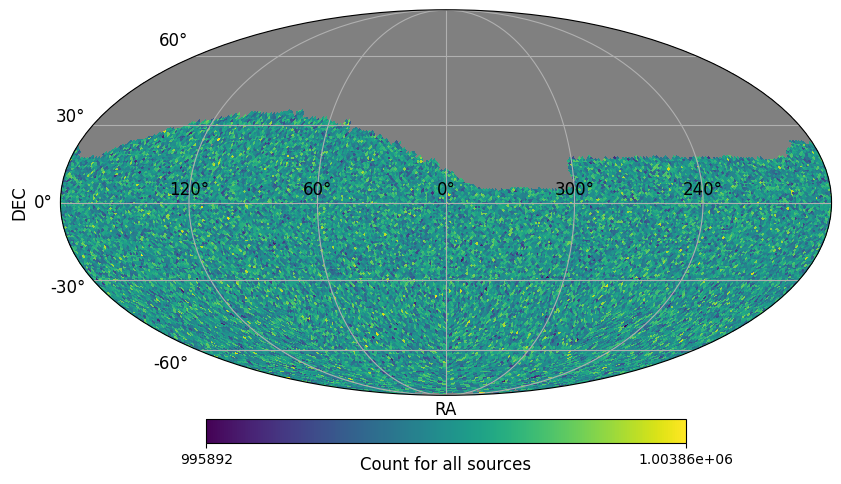

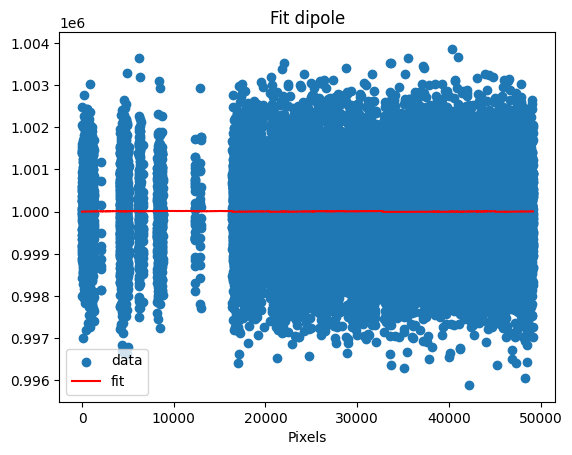

In [17]:
init =  (1e6, 0, 100, 40)
count_thMapper.fit_dipole("Masked", init)

Saving DetectMap_m5band_i in Simul_Figures/Simul_Magnitude/DetectMap_m5band_i.pdf


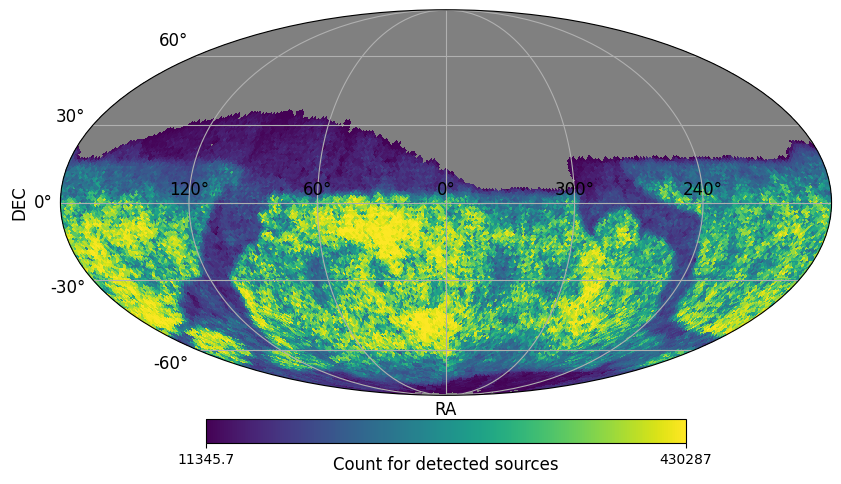

In [18]:
countDetectedMapper = CountMapper.from_map(count_thMapper.map * ratioMapper.map)
countDetectedMapper._set_suffixTextPlot(unit = "detected sources")
countDetectedMapper.set_mask()
countDetectedMapper.plot("Masked", norm="hist")

output_path = "Simul_Figures/Simul_Magnitude/"
get_savefig(plt, output_path, f"DetectMap_m5band_{band}")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.396e+09 (χ²/ndof = 28412.6)│              Nfcn = 530              │
│ EDM = 0.000287 (Goal: 0.0002)    │            time = 7.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │195.4069e3 │ 0.0029e3  │ -0.0029e3  │  0.0029e3  │    0    │         │       │
│ 1 │ A    │510.883e-3 │ 0.031e-3  │ -0.031e-3  │  0.030e-3  │    0    │    1    │       │
│ 2 │ ra   │  254.103  │   0.012   │   -0.012   │   0.012    │    0    │   360   │       │
│ 3 │ dec  │ -77.1729  │  0.0026   │  -0.0026   │   0.0027   │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -2.9    │    2.9    │ -0.031e-3 │ 0.030e-3  │  -0.012   │   0.012   │  -0.0026  │  0.0027   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │          N*           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│  N* │        8.35 -53.3394e-6     3.35e-3    2.841e-3 │
│   A │ -53.3394e-6    9.35e-10    -34.0e-9    -32.2e-9 │
│  ra │     3.35e-3    -34.0e-9    0.000135       -0e-6 │
│ dec │    2.841e-3    -32.2e-9       -0e-6     6.9e-06 │
└─────┴─────────────────────────────────────────────────┘

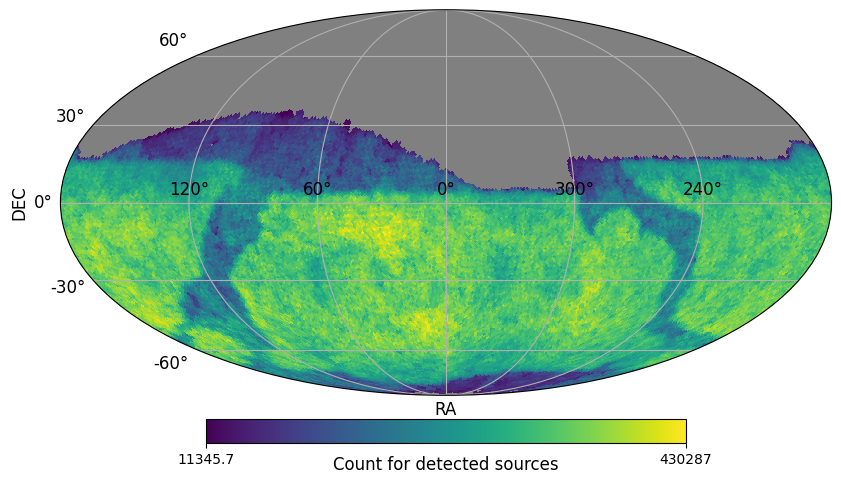

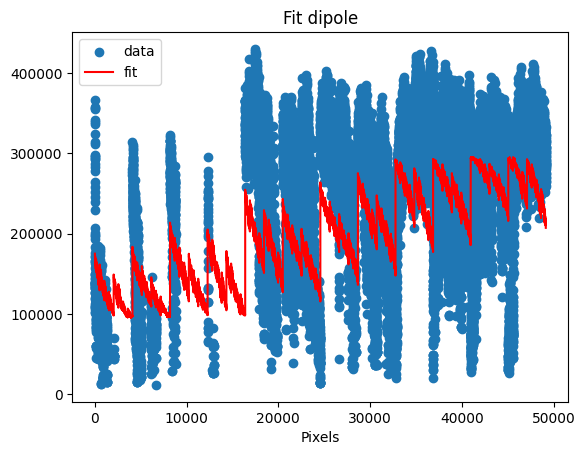

In [19]:
init =  (1e5, 1, 100, 40)
countDetectedMapper.fit_dipole("Masked", init)

Saving ObservMap_m5band_i_poissOnly in Simul_Figures/Simul_Magnitude/ObservMap_m5band_i_poissOnly.pdf


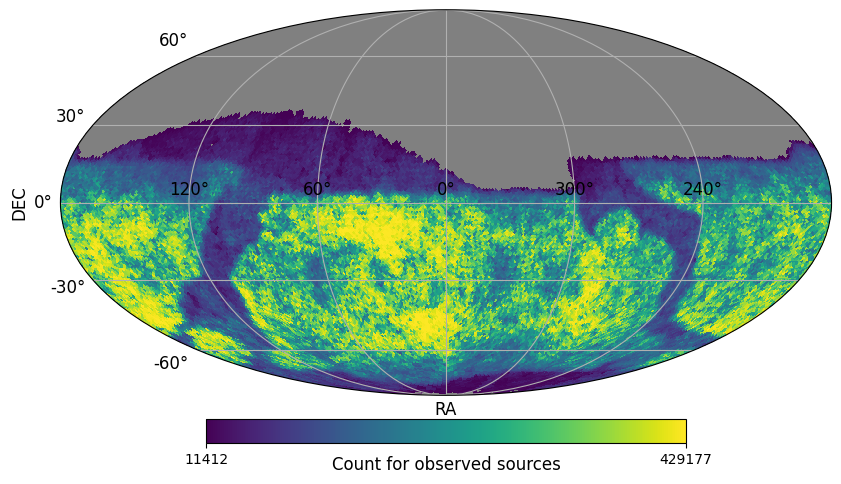

In [20]:
countObservedMapper = CountMapper.from_map(np.random.poisson(countDetectedMapper.map))
countObservedMapper._set_suffixTextPlot(unit = "observed sources")
countObservedMapper.set_mask(dm.m5iMasked.mask)
countObservedMapper.plot("Masked", norm='hist')

output_path = "Simul_Figures/Simul_Magnitude/"
get_savefig(plt, output_path, f"ObservMap_m5band_{band}_poissOnly")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.396e+09 (χ²/ndof = 28412.2)│              Nfcn = 560              │
│ EDM = 0.000253 (Goal: 0.0002)    │            time = 7.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │195.4097e3 │ 0.0029e3  │ -0.0029e3  │  0.0029e3  │    0    │         │       │
│ 1 │ A    │510.886e-3 │ 0.031e-3  │ -0.031e-3  │  0.030e-3  │    0    │    1    │       │
│ 2 │ ra   │  254.118  │   0.012   │   -0.012   │   0.012    │    0    │   360   │       │
│ 3 │ dec  │ -77.1658  │  0.0026   │  -0.0026   │   0.0027   │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -2.9    │    2.9    │ -0.031e-3 │ 0.030e-3  │  -0.012   │   0.012   │  -0.0026  │  0.0027   │
│  Valid   │   True    │   False   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │          N*           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│  N* │        8.35 -53.3353e-6     3.35e-3    2.842e-3 │
│   A │ -53.3353e-6    9.34e-10    -33.9e-9    -32.2e-9 │
│  ra │     3.35e-3    -33.9e-9    0.000135       -0e-6 │
│ dec │    2.842e-3    -32.2e-9       -0e-6     6.9e-06 │
└─────┴─────────────────────────────────────────────────┘

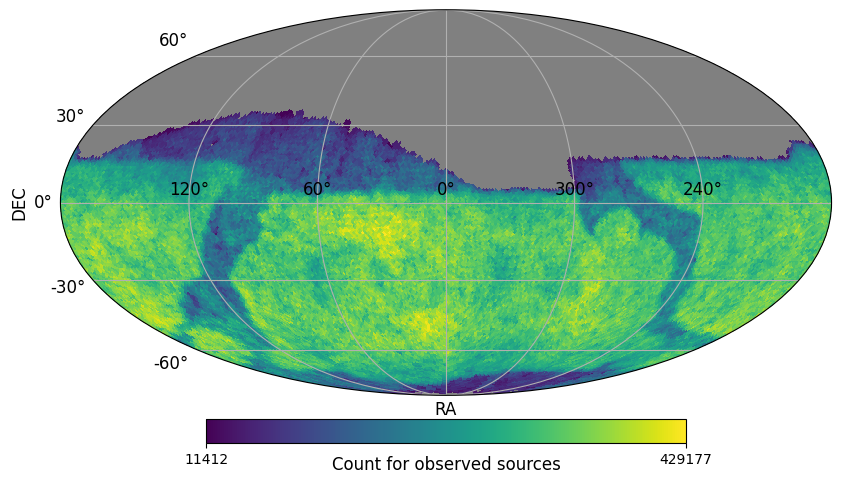

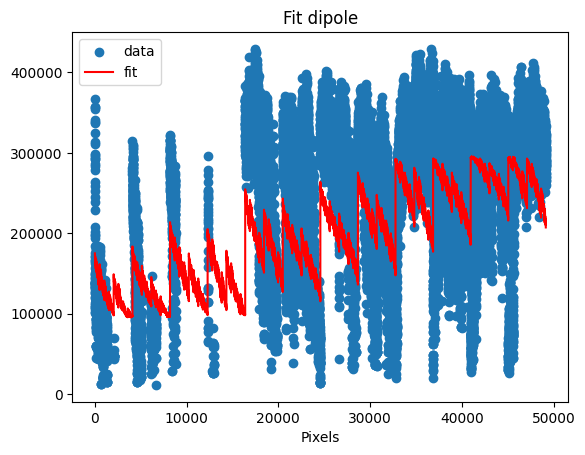

In [21]:
init =  (1e5, 1, 100, 40)
countObservedMapper.fit_dipole("Masked", init)

/tmp/ipykernel_41831/3163810802.py:1: RuntimeWarning: invalid value encountered in divide
  countCorrectedMapper = CountMapper.from_map(countObservedMapper.map / ratioMapper.map)


Saving CorrectMap_m5band_i_poissOnly in Simul_Figures/Simul_Magnitude/CorrectMap_m5band_i_poissOnly.pdf


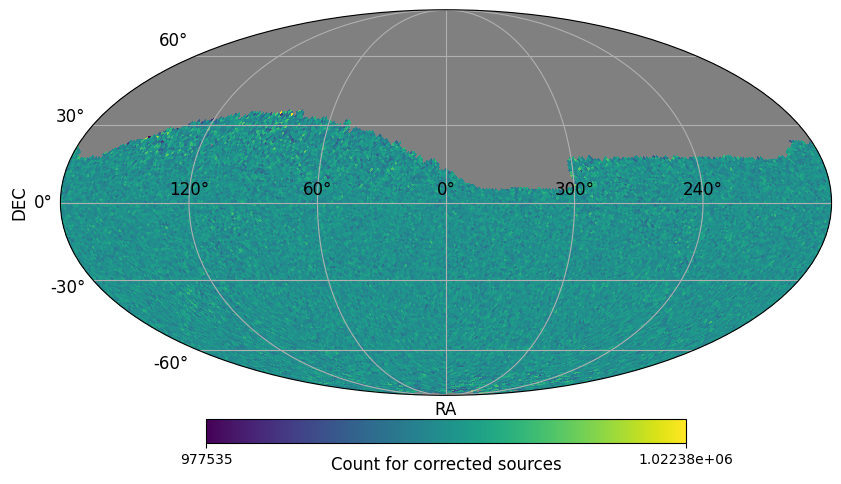

In [22]:
countCorrectedMapper = CountMapper.from_map(countObservedMapper.map / ratioMapper.map)
countCorrectedMapper.fillna()
countCorrectedMapper._set_suffixTextPlot(unit = "corrected sources")
countCorrectedMapper.set_mask()
countCorrectedMapper.plot("Masked")

output_path = "Simul_Figures/Simul_Magnitude/"
get_savefig(plt, output_path, f"CorrectMap_m5band_{band}_poissOnly")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.898e+05 (χ²/ndof = 3.9)  │              Nfcn = 365              │
│ EDM = 6.77e-06 (Goal: 0.0002)    │            time = 5.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 999.997e3 │  0.007e3  │  -0.007e3  │  0.007e3   │    0    │         │       │
│ 1 │ A    │   46e-6   │   9e-6    │   -9e-6    │    9e-6    │    0    │    1    │       │
│ 2 │ ra   │    277    │    12     │    -12     │     12     │    0    │   360   │       │
│ 3 │ dec  │    -22    │    17     │    -16     │     17     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -7     │     7     │   -9e-6   │   9e-6    │    -12    │    12     │    -16    │    17     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────┐
│     │           N*            A           ra          dec │
├─────┼─────────────────────────────────────────────────────┤
│  N* │         50.4 -12.92248e-6            0           80 │
│   A │ -12.92248e-6     8.38e-11   1.62412e-6 -29.10264e-6 │
│  ra │            0   1.62412e-6          150       0.01e3 │
│ dec │           80 -29.10264e-6       0.01e3          288 │
└─────┴─────────────────────────────────────────────────────┘

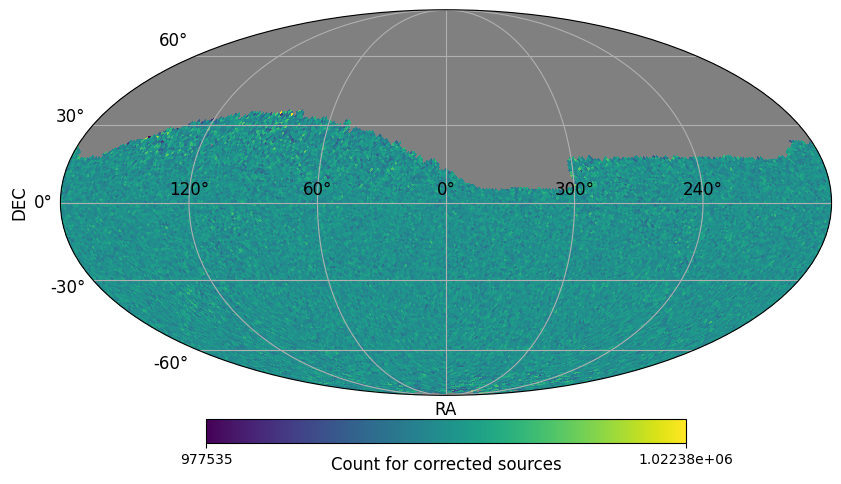

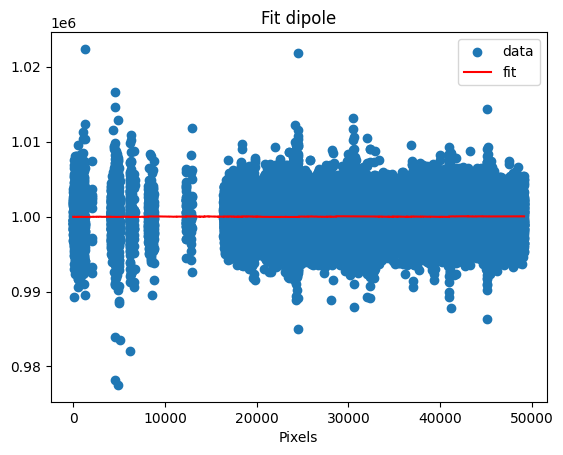

In [23]:
init =  (1e6, 0, 100, 40)
countCorrectedMapper.fit_dipole("Masked", init)

## Smoothing the map

Saving SmoothMap_m5band_i_poissOnly in Simul_Figures/Simul_Magnitude/SmoothMap_m5band_i_poissOnly.pdf


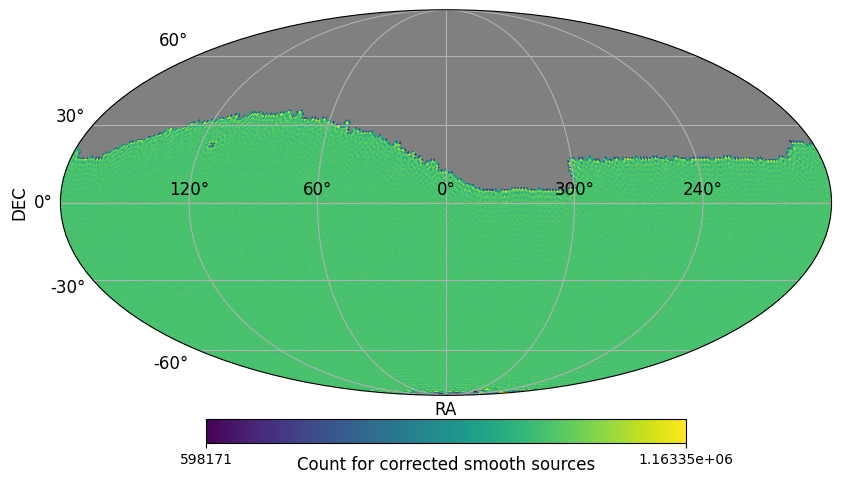

In [24]:
countSmoothMapper = CountMapper.from_map(hp.smoothing(countCorrectedMapper.map, nest=True, sigma=0.005))
countSmoothMapper._set_suffixTextPlot(unit = "corrected smooth sources")
countSmoothMapper.set_mask(countCorrectedMapper.mapMasked.mask)
countSmoothMapper.plot("Masked")

output_path = "Simul_Figures/Simul_Magnitude/"
get_savefig(plt, output_path, f"SmoothMap_m5band_{band}_poissOnly")